# 02 — Training Demo

This notebook demonstrates the full training pipeline:
1. Loading and inspecting the dataset
2. Building the HTDemucs model
3. Running a short training loop
4. Visualizing training curves

For full training, use the CLI: `python scripts/train.py --config configs/unconditioned.yaml`

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path(".").resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, random_split

from src.data.dataset import GuitarDataset
from src.data.manifests import load_manifest
from src.models.factory import build_model
from src.training.engine import TrainConfig, train_model
from src.utils.io import load_config

%matplotlib inline
plt.rcParams["figure.dpi"] = 100

## 1. Configuration

In [2]:
config = load_config(REPO_ROOT / "configs" / "unconditioned.yaml")

DEMO_EPOCHS = 1
BATCH_SIZE = 2
SEGMENT_SECONDS = config["audio"]["segment_seconds"]
LEARNING_RATE = config["training"]["learning_rate"]

print(f"Model: {config['model']['name']}")
print(f"Segment: {SEGMENT_SECONDS}s")
print(f"Demo epochs: {DEMO_EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")

Model: htdemucs
Segment: 4s
Demo epochs: 1
Batch size: 2


## 2. Load dataset

In [3]:
manifest = load_manifest(REPO_ROOT / config["dataset"]["manifest"], resolve_root=REPO_ROOT)
train_entries = [e for e in manifest if e["split"] == config["dataset"]["train_split"]]

dataset = GuitarDataset(
    train_entries[:5],
    sample_length=SEGMENT_SECONDS,
    normalize=config["dataset"]["normalize"],
    use_notes=False,
)
print(f"Dataset samples: {len(dataset)}")

generator = torch.Generator().manual_seed(42)
train_size = int(len(dataset) * 0.8)
valid_size = len(dataset) - train_size
train_ds, valid_ds = random_split(dataset, [train_size, valid_size], generator=generator)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_ds)} samples, {len(train_loader)} batches")
print(f"Valid: {len(valid_ds)} samples, {len(valid_loader)} batches")

Dataset samples: 1111
Train: 888 samples, 444 batches
Valid: 223 samples, 112 batches


## 3. Inspect a batch

Audio batch shape: torch.Size([2, 3, 2, 176400])
  [batch, sources(mix+g1+g2), channels, time]
Notes batch shape: torch.Size([2, 256, 176400])


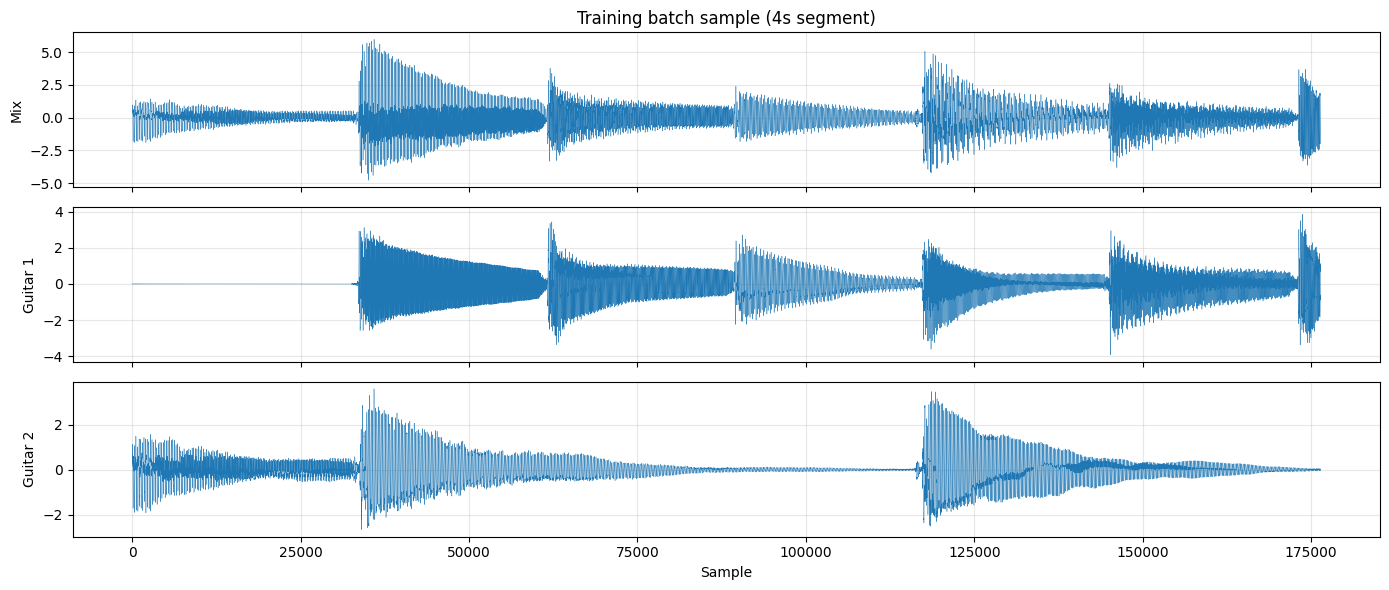

In [4]:
batch_audio, batch_notes = next(iter(train_loader))
print(f"Audio batch shape: {batch_audio.shape}")
print(f"  [batch, sources(mix+g1+g2), channels, time]")
print(f"Notes batch shape: {batch_notes.shape}")

mix_sample = batch_audio[0, 0, 0].numpy()
g1_sample = batch_audio[0, 1, 0].numpy()
g2_sample = batch_audio[0, 2, 0].numpy()

fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True)
for ax, wav, label in zip(axes, [mix_sample, g1_sample, g2_sample],
                          ["Mix", "Guitar 1", "Guitar 2"]):
    ax.plot(wav, linewidth=0.3)
    ax.set_ylabel(label)
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel("Sample")
axes[0].set_title("Training batch sample (4s segment)")
plt.tight_layout()
plt.show()

## 4. Build model

In [5]:
model = build_model(config["model"]["name"], config["model"].get("kwargs", {}))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Device: {device}")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model size: {total_params * 4 / 1e6:.1f} MB (float32)")

Device: cpu
Total parameters: 26,894,916
Trainable parameters: 26,894,916
Model size: 107.6 MB (float32)


## 5. Train (demo — few epochs)

In [ ]:
train_config = TrainConfig(
    epochs=DEMO_EPOCHS,
    learning_rate=LEARNING_RATE,
    use_sum_loss=False,
    checkpoint_interval=DEMO_EPOCHS,
    use_notes=False,
    use_amp="cuda" in device.type,
    gradient_clip=5.0,
)

checkpoints_dir = REPO_ROOT / "outputs" / "checkpoints" / "notebook_demo"
log_dir = REPO_ROOT / "outputs" / "logs" / "notebook_demo"

history = train_model(
    model, train_loader, valid_loader,
    checkpoints_dir=checkpoints_dir,
    log_dir=log_dir,
    config=train_config,
    device=device,
)
print(f"\nFinished {len(history)} epochs.")

## 6. Plot training curves

In [ ]:
epochs = [h["epoch"] + 1 for h in history]
train_losses = [h["train_loss"] for h in history]
valid_losses = [h["valid_loss"] for h in history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs, train_losses, "o-", label="Train")
ax1.plot(epochs, valid_losses, "s-", label="Valid")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss (PIT L1)")
ax1.set_title("Training & Validation Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

if "lr" in history[0]:
    lrs = [h["lr"] for h in history]
    ax2.plot(epochs, lrs, "o-", color="tab:green")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Learning Rate")
    ax2.set_title("Learning Rate Schedule")
    ax2.grid(True, alpha=0.3)
    ax2.ticklabel_format(style="sci", axis="y", scilimits=(0,0))

plt.tight_layout()
plt.show()